In [60]:
import io
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import os

In [63]:
#RAW_DIR = r"F:\Dropbox (Personal)\project\muni_bonds\data\raw\Fed"
DIR = r"D:\Dropbox\project\muni_bonds\data"
PROC_DIR = r"D:\Dropbox\project\muni_bonds\data\processed"
RAW_DIR = r"D:\Dropbox\project\muni_bonds\data\raw\Fed"
OUT_DIR = r"D:\Dropbox\project\muni_bonds\outputs"
#os.makedirs(DIR, exist_ok=True)

# Municipal Securities Ownership by Sector
Source: Federal Reserve Z.1 Financial Accounts, Table L.212

In [21]:
""" Pull data from Fed Financial Accounts """
# https://www.federalreserve.gov/releases/z1/20260109/html/l212.htm
# ---------------------------------------------------------------------------
# Series definitions — asset/holder side of Z.1 Table L.212
# ---------------------------------------------------------------------------
SERIES = {
    "Households & Nonprofits":        "LM153062005",
    "Mutual Funds":                   "LM653062003",
    "ETFs":                           "LM563062003",
    "Money Market Funds":             "FL633062000",
    "Prop-Casualty Insurance":        "LM513062005",
    "Life Insurance":                 "LM543062005",
    "Depository Institutions":        "LM763062000",
    "State & Local Govts":            "LM213062003",
    "Retirement Funds (Fed)":         "LM343062033",
    "Retirement Funds (S&L)":         "LM223062043",
    "Foreign (Rest of World)":        "LM263062003",
    "Brokers & Dealers":              "LM663062003",
    "GSEs":                           "LM403062005",
    "Closed-End Funds":               "LM553062003",
    "Credit Unions":                  "LM473062005",
    "Other Financial":                "FL503062003",
    "Nonfin. Corporate":              "LM103062003",
    "Nonfin. Noncorporate":           "LM113062003",
    "Foreign Banks in US":            "LM753062003",
    "Banks in US-Affiliated Areas":   "LM743062003",
}

FRED_CSV = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=BOGZ1{code}Q"

# ---------------------------------------------------------------------------
# Step 1: Download raw CSVs and save to disk
# ---------------------------------------------------------------------------
print("Downloading and saving raw Z.1 L.212 series from FRED...")
for label, code in SERIES.items():
    url = FRED_CSV.format(code=code)
    out_path = os.path.join(RAW_DIR, f"BOGZ1{code}Q.csv")
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        with open(out_path, "w") as f:
            f.write(resp.text)
        print(f"  saved  BOGZ1{code}Q.csv")
    except Exception as e:
        print(f"  FAILED {label} ({code}): {e}")

print(f"\nRaw files saved to: {RAW_DIR}")

  saved  BOGZ1LM153062005Q.csv
  saved  BOGZ1LM653062003Q.csv
  saved  BOGZ1LM563062003Q.csv
  saved  BOGZ1FL633062000Q.csv
  saved  BOGZ1LM513062005Q.csv
  saved  BOGZ1LM543062005Q.csv
  saved  BOGZ1LM763062000Q.csv
  saved  BOGZ1LM213062003Q.csv
  saved  BOGZ1LM343062033Q.csv
  saved  BOGZ1LM223062043Q.csv
  saved  BOGZ1LM263062003Q.csv
  saved  BOGZ1LM663062003Q.csv
  saved  BOGZ1LM403062005Q.csv
  saved  BOGZ1LM553062003Q.csv
  saved  BOGZ1LM473062005Q.csv
  saved  BOGZ1FL503062003Q.csv
  saved  BOGZ1LM103062003Q.csv
  saved  BOGZ1LM113062003Q.csv
  saved  BOGZ1LM753062003Q.csv
  saved  BOGZ1LM743062003Q.csv

Raw files saved to: D:\Dropbox\project\muni_bonds\data\raw\Fed


In [25]:
# ---------------------------------------------------------------------------
# Step 2: Load saved CSVs and merge into one DataFrame
# ---------------------------------------------------------------------------
frames = {}
for label, code in SERIES.items():
    path = os.path.join(RAW_DIR, f"BOGZ1{code}Q.csv")
    if not os.path.exists(path):
        print(f"  MISSING {label}")
        continue
    df = pd.read_csv(path, parse_dates=["observation_date"])
    df = df.rename(columns={"observation_date": "date"})
    df = df.set_index("date")
    df.columns = [label]
    df[label] = pd.to_numeric(df[label], errors="coerce")
    frames[label] = df[label]

raw_df = pd.DataFrame(frames)
raw_df.to_csv(os.path.join(PROC_DIR, "ffa_muni_holdings_sector.csv"))

In [27]:
# drop NA
df_tr = (raw_df / 1_000).dropna(how="all")   # billions → trillions
print(f"Data spans {df_tr.index.min().year}–{df_tr.index.max().year}  ({len(df_tr)} quarters)")

Data spans 1945–2025  (302 quarters)


In [50]:
# ---------------------------------------------------------------------------
# Categorize ownership
# ---------------------------------------------------------------------------
df_plot = df_tr.copy()

# Drop foreign holders (focus on US)
df_plot = df_plot.drop(columns=["Foreign (Rest of World)", "Foreign Banks in US",
                                 "Banks in US-Affiliated Areas"], errors="ignore")

# Insurance = P&C + Life combined
df_plot["Insurance"] = (
    df_plot.pop("Prop-Casualty Insurance").fillna(0)
    + df_plot.pop("Life Insurance").fillna(0)
)

# Mutual Funds = open-end + ETFs
df_plot["Mutual Funds, ETFs & CEFs"] = (
    df_plot.pop("Mutual Funds").fillna(0)
    + df_plot.pop("ETFs").fillna(0)
    + df_plot.pop("Closed-End Funds").fillna(0)
)

# Retirement Funds = federal + state & local employee pension funds
df_plot["Retirement Funds"] = (
    df_plot.pop("Retirement Funds (Fed)").fillna(0)
    + df_plot.pop("Retirement Funds (S&L)").fillna(0)
)

# Rename
df_plot = df_plot.rename(columns={"Households & Nonprofits": "Households"})

# Remaining holders
other_cols = ["Closed-End Funds", "Other Financial", "Depository Institutions", "State & Local Govts", 
              "Brokers & Dealers", "Retirement Funds (Fed)", "Retirement Funds (S&L)"
              "GSEs", "Credit Unions", "Nonfin. Corporate", "Nonfin. Noncorporate"]
other_cols = [c for c in other_cols if c in df_plot.columns]
df_plot["Other"] = df_plot[other_cols].fillna(0).sum(axis=1)
df_plot = df_plot.drop(columns=other_cols)

# Institutional = everything except Households
INSTITUTIONAL = ["Insurance", "Mutual Funds, ETFs & CEFs", "Money Market Funds", "Other"]

ORDER = ["Households"] + INSTITUTIONAL
df_plot = df_plot[[c for c in ORDER if c in df_plot.columns]]
df_plot = df_plot[df_plot.sum(axis=1) > 0]

# Summary series
total_us    = df_plot.sum(axis=1)
inst_share  = df_plot[INSTITUTIONAL].sum(axis=1) / total_us * 100
hh_share    = df_plot["Households"] / total_us * 100

print("Latest quarter (US only):")
for col in df_plot.columns:
    pct = df_plot[col].iloc[-1] / total_us.iloc[-1] * 100
    print(f"  {col:35s}  ${df_plot[col].iloc[-1]:.2f}T  ({pct:.1f}%)")
print(f"\n  {'Institutional total':35s}  {inst_share.iloc[-1]:.1f}%")
print(f"  {'Households':35s}  {hh_share.iloc[-1]:.1f}%")

Latest quarter (US only):
  Households                           $2038.29T  (55.0%)
  Insurance                            $379.00T  (10.2%)
  Mutual Funds, ETFs & CEFs            $1060.84T  (28.6%)
  Money Market Funds                   $139.70T  (3.8%)
  Other                                $89.76T  (2.4%)

  Institutional total                  45.0%
  Households                           55.0%


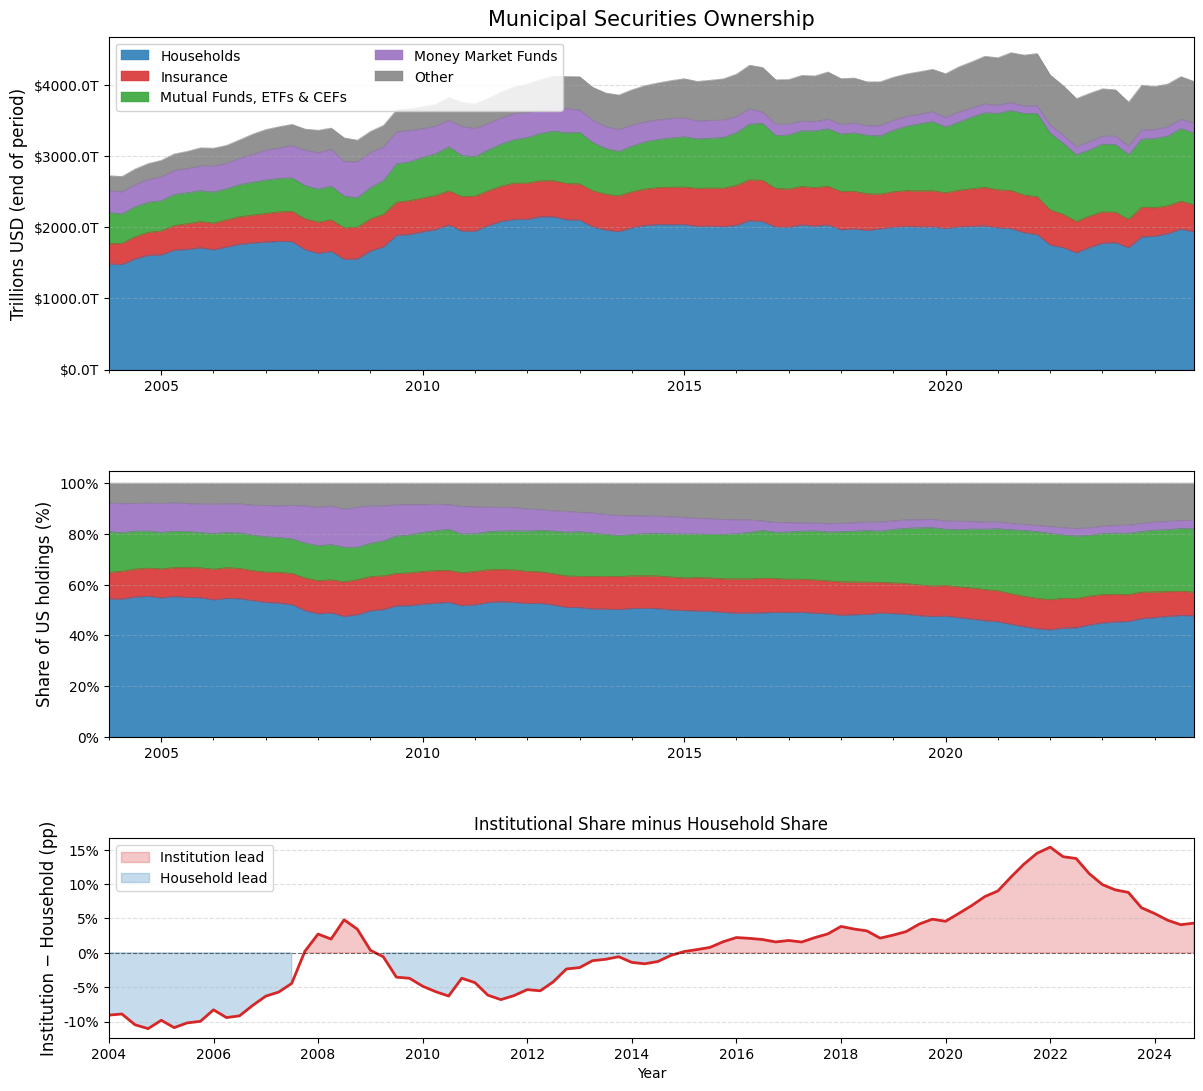

In [78]:
# ---------------------------------------------------------------------------
# Plot: institutionalization trend
# ---------------------------------------------------------------------------
df_plot    = df_plot[(df_plot.index.year >= 2004) & (df_plot.index.year <= 2024)]
total_us   = total_us[(total_us.index.year >= 2004) & (total_us.index.year <= 2024)]
hh_share   = hh_share[(hh_share.index.year >= 2004) & (hh_share.index.year <= 2024)]
inst_share = inst_share[(inst_share.index.year >= 2004) & (inst_share.index.year <= 2024)]

COLORS = {
    "Households":                   "#1f77b4",
    "Insurance":                    "#d62728",
    "Mutual Funds, ETFs & CEFs":    "#2ca02c",
    "Money Market Funds":           "#9467bd",
    "Other":                        "#7f7f7f",
}
colors = [COLORS[c] for c in df_plot.columns]

df_share = df_plot.div(total_us, axis=0).mul(100)

fig = plt.figure(figsize=(14, 13))
gs  = fig.add_gridspec(3, 1, height_ratios=[2, 1.6, 1.2], hspace=0.38)

# Federal Reserve Z.1 Financial Accounts, Table L.212
# ── Panel 1: stacked area — absolute levels ──────────────────────────────
ax1 = fig.add_subplot(gs[0])
df_plot.plot.area(ax=ax1, color=colors, linewidth=0.3, alpha=0.85)
ax1.set_title(
    "Municipal Securities Ownership",
    fontsize=15, pad=8,
)
ax1.set_ylabel("Trillions USD (end of period)", fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}T"))
ax1.legend(loc="upper left", fontsize=10, framealpha=0.85, ncol=2)
ax1.set_xlim(df_plot.index.min(), df_plot.index.max())
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.set_xlabel("")

# ── Panel 2: stacked area — ownership share (%) ──────────────────────────
ax2 = fig.add_subplot(gs[1])
df_share.plot.area(ax=ax2, color=colors, linewidth=0.3, alpha=0.85, legend=False)
ax2.set_ylabel("Share of US holdings (%)", fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_xlim(df_plot.index.min(), df_plot.index.max())
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_xlabel("")

# ── Panel 3: Institutional minus Household share difference ──────────────
ax3 = fig.add_subplot(gs[2])
diff = inst_share - hh_share
ax3.plot(diff.index, diff.values, color="#d62728", lw=2)
ax3.fill_between(diff.index, diff.values, 0,
                 where=(diff >= 0), alpha=0.25, color="#d62728", label="Institution lead")
ax3.fill_between(diff.index, diff.values, 0,
                 where=(diff < 0),  alpha=0.25, color="#1f77b4", label="Household lead")
ax3.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)

# # Mark crossover
# cross_idx = (diff >= 0).idxmax()
# if pd.notna(cross_idx) and diff[cross_idx] >= 0:
#     ax3.axvline(cross_idx, color="black", lw=1, linestyle=":", alpha=0.7)
#     ax3.text(cross_idx, diff.max() * 0.05, f" Crossover\n {cross_idx.year}",
#              fontsize=8, va="bottom", color="black")

ax3.set_ylabel("Institution − Household (pp)", fontsize=12)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax3.set_xlim(df_plot.index.min(), df_plot.index.max())
ax3.legend(fontsize=10, loc="upper left")
ax3.set_title("Institutional Share minus Household Share", fontsize=12)
ax3.grid(axis="y", linestyle="--", alpha=0.4)
ax3.set_xlabel("Year")

plt.savefig(os.path.join(OUT_DIR, "plots/muni_ownership.pdf"), bbox_inches="tight")
plt.show()